<a href="https://colab.research.google.com/github/dkang1630/Conductor_Image_Classification/blob/main/CNN_Coductor_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import torch
import random
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
#from torchvision.models import resnet18
from PIL import Image
from google.colab import drive
from sklearn.model_selection import train_test_split
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Set random seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Torch random tensor:", torch.rand(3))  # Generate a random tensor with 3 elements
print("Numpy random array:", np.random.rand(3))  # Generate a random array with 3 elements
print("Python random number:", random.random())  # Generate a random float

Torch random tensor: tensor([0.8823, 0.9150, 0.3829])
Numpy random array: [0.37454012 0.95071431 0.73199394]
Python random number: 0.6394267984578837


In [ ]:
# Paths
BASE_PATH = "/content/drive/My Drive/Conductor_Image_Detection/Images/Lab_experiment/Classified"
ORIGINAL_PATH = os.path.join(BASE_PATH, "Original")
GVN_PATH = os.path.join(BASE_PATH, "GVN_Processed")
CLASSES = ["Abrasion", "Corrosion", "Fretting", "Healthy", "Minor_Abrasion", "Minor_Corrosion"]

In [ ]:
#Image Transformations
IMG_SIZE = 128
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) #normalize to [-1, 1]
])

In [ ]:
#Custom dataset class
class CustomDataset(Dataset):
  def __init__(self, base_path, classes, transform=None):
    self.data = []
    self.labels = []
    self.transform = transform
    # self.class_map = {
    #     'Abrasion': 0,
    #     'Corrosion': 1,
    #     'Fretting': 2,
    #     'Healthy': 3,
    #     'Minor_Abrasion': 4,
    #     'Minor_Corrosion': 5
    # }
    self.class_map = {class_name: idx for idx, class_name in enumerate(classes)}
    self.classes = classes #store the classes

    for folder_name in os.listdir(base_path):
      folder_path = os.path.join(base_path, folder_name)
      if os.path.isdir(folder_path):
        #Assign label on the folder name
        label = self.class_map.get(folder_name, None)
        if label is not None:
          for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            self.data.append(img_path)
            self.labels.append(label)

  def __len__(self):
    return len(self.data)

  def __getitem__(self, idx):
    img_path = self.data[idx]
    label = self.labels[idx]
    image = Image.open(img_path).convert("L") #L for grayscale

    if self.transform:
      image = self.transform(image)

    return image, label

def split_data(base_path, train_ratio=0.7, test_ratio=0.3, random_state=123):
    dataset = CustomDataset(base_path, CLASSES, transform=None)  # No transform for now
    images = dataset.data
    labels = dataset.labels

    # Split the data into train and test using the specified ratio
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=(1 - train_ratio), random_state=random_state, stratify=labels
    )

    return X_train, X_test, y_train, y_test


In [ ]:
oringial_dataset = CustomDataset(ORIGINAL_PATH, CLASSES, transform=transform)
GVN_dataset = CustomDataset(GVN_PATH, CLASSES, transform=transform)

# Split Original Dataset
#X_train_or, X_val_or, X_test_or, y_train_or, y_val_or, y_test_or = split_data(ORIGINAL_PATH)

# Split GVN Dataset
X_train_gvn, X_test_gvn, y_train_gvn, y_test_gvn = split_data(GVN_PATH, train_ratio=0.7, test_ratio=0.3)

# Function to print class distribution
def print_class_distribution(y_data, classes):
    distribution = np.bincount(y_data)
    for i, count in enumerate(distribution):
        print(f"Class '{classes[i]}': {count}")

# Display the distributions
print(f"Training data size: {len(X_train_gvn)}")
print(f"Test data size: {len(X_test_gvn)}")

print("\nTraining labels distribution:")
print_class_distribution(y_train_gvn, CLASSES)

print("\nTest labels distribution:")
print_class_distribution(y_test_gvn, CLASSES)

# Convert split data into torch datasets using indices
train_indices = range(len(X_train_gvn))
test_indices = range(len(X_test_gvn))

train_dataset_gvn = torch.utils.data.Subset(GVN_dataset, train_indices)
test_dataset_gvn = torch.utils.data.Subset(GVN_dataset, test_indices)

# DataLoader for training and testing
train_loader_gvn = DataLoader(train_dataset_gvn, batch_size=32, shuffle=True)
test_loader_gvn = DataLoader(test_dataset_gvn, batch_size=32, shuffle=False)

Training data size: 745
Test data size: 320

Training labels distribution:
Class 'Abrasion': 25
Class 'Corrosion': 162
Class 'Fretting': 141
Class 'Healthy': 113
Class 'Minor_Abrasion': 304

Test labels distribution:
Class 'Abrasion': 11
Class 'Corrosion': 69
Class 'Fretting': 61
Class 'Healthy': 49
Class 'Minor_Abrasion': 130


In [ ]:
class CustomCNN(nn.Module):
  def __init__(self, num_classes=6):
    #Call the initializer of the parent class-nn.Module
    super(CustomCNN, self).__init__()

    self.conv1 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=5)
    self.bn1 = nn.BatchNorm2d(5)
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(in_channels=5, out_channels=10, kernel_size=5)
    self.bn2 = nn.BatchNorm2d(10)
    self.fc1 = nn.Linear(in_features=10 * 29 * 29, out_features=120)
    self.fc2 = nn.Linear(in_features=120, out_features=84)
    self.fc3 = nn.Linear(in_features=84, out_features=num_classes)

  def forward(self, x):
    x = self.pool(F.relu(self.bn1(self.conv1(x)))) #Adds Layers 1-3
    x = self.pool(F.relu(self.bn2(self.conv2(x)))) #Adds Layers 4-6
    x = torch.flatten(x,1) # flatten all dimensions except batch
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = CustomCNN(num_classes=6).to(device)
summary(model, input_size=(1, 128, 128))

criteron = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 5, 124, 124]             130
       BatchNorm2d-2          [-1, 5, 124, 124]              10
         MaxPool2d-3            [-1, 5, 62, 62]               0
            Conv2d-4           [-1, 10, 58, 58]           1,260
       BatchNorm2d-5           [-1, 10, 58, 58]              20
         MaxPool2d-6           [-1, 10, 29, 29]               0
            Linear-7                  [-1, 120]       1,009,320
            Linear-8                   [-1, 84]          10,164
            Linear-9                    [-1, 6]             510
Total params: 1,021,414
Trainable params: 1,021,414
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.06
Forward/backward pass size (MB): 1.90
Params size (MB): 3.90
Estimated Total Size (MB): 5.86
-----------------------------------

In [ ]:
def train(model, loader, criterion, optimizer, num_epoches=10):
    print('Start Training')

    for epoch in range(num_epoches):
        running_loss = 0.0
        total = 0
        correct = 0

        model.train()  # set the model to training mode

        for i, data in enumerate(tqdm(loader)):
            # get the inputs; [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to the device

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # the class with the highest energy is what chosen as prediction
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            # accumulate loss for this batch
            running_loss += loss.item()

            # Print statistics for every batch
            print(f'Batch {i + 1:5d} - Loss: {running_loss / (i + 1):.3f}', end='\r')

        # Print accuracy and loss at the end of each epoch
        print(f'\nEpoch {epoch + 1} finished!')
        print(f'Average loss for epoch {epoch + 1}: {running_loss / len(loader):.3f}')
        print(f'Accuracy of the network on epoch {epoch + 1}: {100 * correct // total}%')

    print('\nFinished Training')


In [ ]:
# Train model
train(model, train_loader_gvn, criteron, optimizer, 10)

Start Training


  4%|▍         | 1/24 [00:00<00:22,  1.04it/s]

  8%|▊         | 2/24 [00:01<00:13,  1.63it/s]

 12%|█▎        | 3/24 [00:01<00:10,  1.98it/s]

 17%|█▋        | 4/24 [00:02<00:09,  2.17it/s]

...

 83%|████████▎ | 20/24 [00:08<00:01,  2.80it/s]

 88%|████████▊ | 21/24 [00:08<00:01,  2.83it/s]

 92%|█████████▏| 22/24 [00:08<00:00,  2.77it/s]

100%|██████████| 24/24 [00:09<00:00,  2.55it/s]

Batch    24 - Loss: 0.043
Epoch 10 finished!
Average loss for epoch 10: 0.043
Accuracy of the network on epoch 10: 99%

Finished Training


In [ ]:
#Testing
def evaluation(model, loader):
  correct = 0
  total = 0

  with torch.no_grad():
    for data in tqdm(loader):
      images, labels = data
      #Calculate outputs by runnung images through network
      outputs = model(images)
      #The class with the highest energy is chosen as prediction
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  print(f'\nAccuracy of the nework on the test images: {100 * correct // total}%')


In [ ]:
#Save trained model
# CNN_MODEL_PATH = './cnn_model.pth'
# torch.save(model.state_dict(), CNN_MODEL_PATH)

In [ ]:
#load saved model
model = CustomCNN().to(device)
model.load_state_dict(torch.load('/content/drive/My Drive/Conductor_Image_Detection/cnn_model.pth'))
model.eval()

<ipython-input-180-faf7aa50b5f1>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/My Drive/Conductor_Image_Detection/cnn_mod

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/My Drive/Conductor_Image_Detection/cnn_model.pth'

In [ ]:
#Evaluate the trained model
evaluation(model, test_loader_gvn)

100%|██████████| 10/10 [00:02<00:00,  4.10it/s]


Accuracy of the nework on the test images: 98%


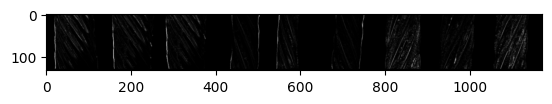

Ground Truth:    Abrasion	Abrasion	Abrasion	Corrosion	Corrosion	Corrosion	Fretting	Fretting	Fretting
CNN Predicted:    Abrasion	Abrasion	Abrasion	Corrosion	Corrosion	Corrosion	Fretting	Fretting	Fretting


In [ ]:
# Imshow function to display images
def imshow(img, is_grayscale=False):
    # If the image is grayscale, skip unnormalization
    if not is_grayscale:
        # Unnormalize pixels for color images
        img = img / 2 + 0.5

    npimg = img.numpy()

    # If it's a grayscale image, make sure the shape is (height, width) for correct display
    if is_grayscale:
        plt.imshow(npimg[0], cmap='gray')  # Assuming a single channel grayscale image
    else:
        # For RGB images, transpose to (height, width, channels) and display
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

    plt.show()

# Get the class labels of your dataset
labels = [label for _, label in test_dataset_gvn]

# Create a stratified batch based on the distribution of the labels
def get_stratified_batch(labels, batch_size):
    # Get indices of each class
    class_indices = {cls: [] for cls in set(labels)}
    for idx, label in enumerate(labels):
        class_indices[label].append(idx)

    # Select batch_size samples with stratified distribution
    batch_indices = []
    for cls, indices in class_indices.items():
        selected_indices = random.sample(indices, batch_size // len(class_indices))
        batch_indices.extend(selected_indices)

    return batch_indices

# Get stratified indices for batch size
batch_size = 9 # Adjust your batch size
batch_indices = get_stratified_batch(labels, batch_size)

# Create batch from selected indices
images = []
batch_labels = []
for idx in batch_indices:
    image, label = test_dataset_gvn[idx]
    images.append(image)
    batch_labels.append(label)

# Stack images into a tensor for model input
image_tensors = torch.stack(images)

# Display the images from the test set
grid = make_grid(image_tensors, nrow=batch_size, normalize=True)
imshow(grid, is_grayscale=True)

# Print images from test set
print('Ground Truth:   ', '\t'.join(f'{CLASSES[batch_labels[j]]:5s}' for j in range(batch_size)))

# Input images into model
outputs = model(image_tensors)
_, predicted = torch.max(outputs, 1)

# Print predicted classes
print('CNN Predicted:   ', '\t'.join(f'{CLASSES[predicted[j]]:5s}' for j in range(batch_size)))